In [1]:
# 1. Imports & Configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis, norm
from scipy.optimize import minimize

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 80)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('muted')
print('All libraries loaded')


All libraries loaded


In [2]:
# 2. Load Data

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train_id = train['Id']
test_id = test['Id']
print(f'Train shape: {train.shape}  |  Test shape: {test.shape}')
print(f'Train columns: {train.shape[1]}  |  Test columns: {test.shape[1]}')


Train shape: (1460, 81)  |  Test shape: (1459, 80)
Train columns: 81  |  Test columns: 80


---
# Exploratory Data Analysis (EDA)


In [3]:
# 3.1 Dataset Overview

print(f'Numerical features : {train.select_dtypes(include=[np.number]).shape[1]}')
print(f'Categorical features: {train.select_dtypes(include=["object"]).shape[1]}')
print(f'Total features      : {train.shape[1] - 2}')  # exclude Id, SalePrice
print()
train.info()


Numerical features : 38
Categorical features: 43
Total features      : 79

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 n

In [4]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


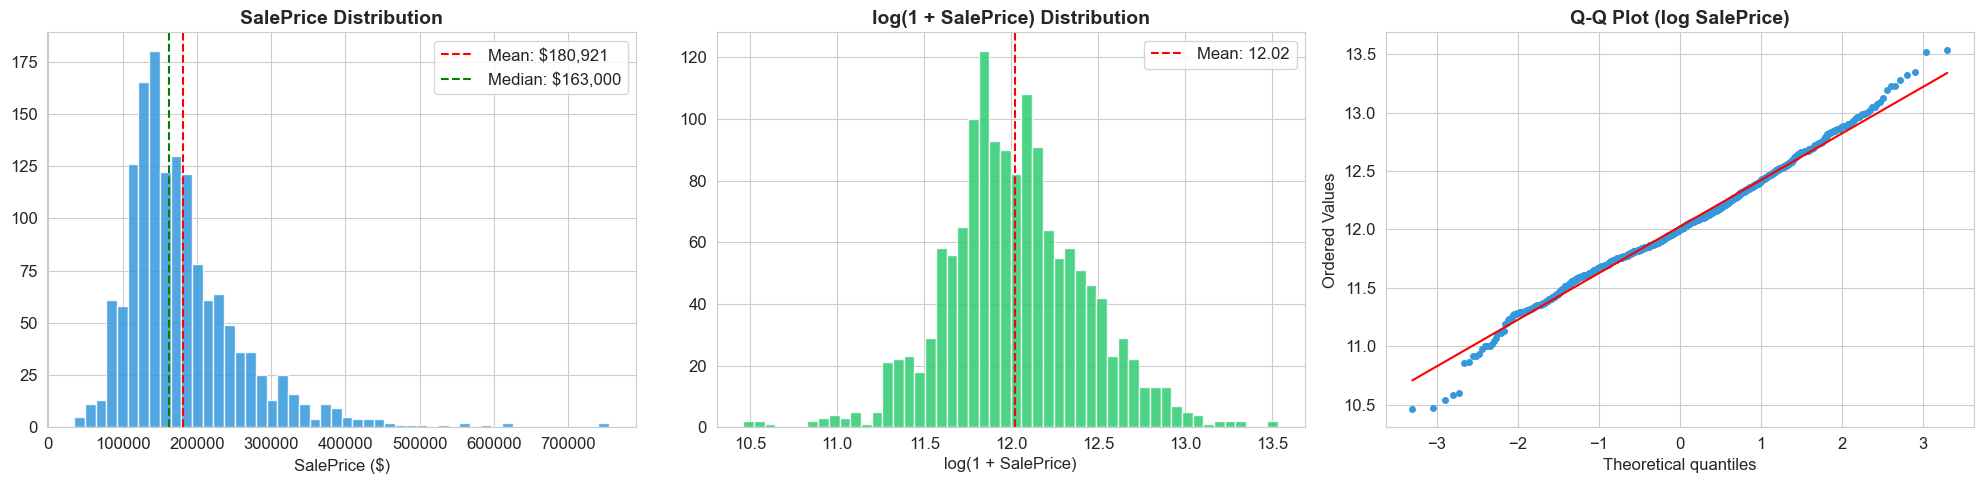

SalePrice  — Skewness: 1.883  |  Kurtosis: 6.536
Log Price  — Skewness: 0.121  |  Kurtosis: 0.810


In [6]:
# 3.2 Target Variable — SalePrice

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Raw distribution
axes[0].hist(train['SalePrice'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(train['SalePrice'].mean(), color='red', linestyle='--', label=f"Mean: ${train['SalePrice'].mean():,.0f}")
axes[0].axvline(train['SalePrice'].median(), color='green', linestyle='--', label=f"Median: ${train['SalePrice'].median():,.0f}")
axes[0].set_title('SalePrice Distribution', fontweight='bold', fontsize=14)
axes[0].set_xlabel('SalePrice ($)')
axes[0].legend()

# Log-transformed distribution
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axvline(log_price.mean(), color='red', linestyle='--', label=f'Mean: {log_price.mean():.2f}')
axes[1].set_title('log(1 + SalePrice) Distribution', fontweight='bold', fontsize=14)
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].legend()

# QQ-plot
from scipy import stats
stats.probplot(log_price, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (log SalePrice)', fontweight='bold', fontsize=14)
axes[2].get_lines()[0].set(markerfacecolor='#3498db', markeredgecolor='#3498db', markersize=4)
axes[2].get_lines()[1].set(color='red')

plt.tight_layout()
plt.show()

print(f'SalePrice  — Skewness: {train["SalePrice"].skew():.3f}  |  Kurtosis: {train["SalePrice"].kurtosis():.3f}')
print(f'Log Price  — Skewness: {log_price.skew():.3f}  |  Kurtosis: {log_price.kurtosis():.3f}')


Features with missing values: 34



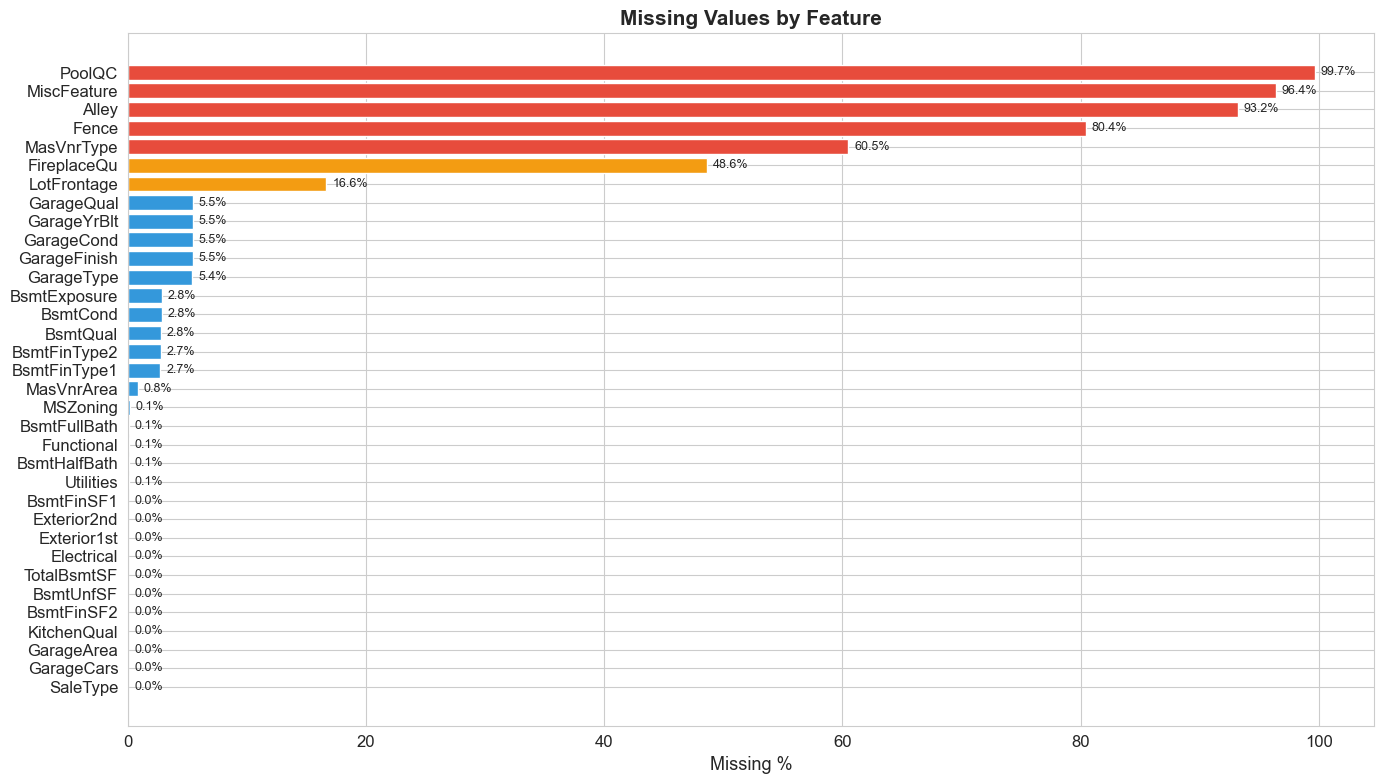

In [7]:
# 3.3 Missing Values Analysis

combined_temp = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)
missing = combined_temp.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(combined_temp) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'Features with missing values: {len(missing_df)}')
print()

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if pct > 50 else '#f39c12' if pct > 10 else '#3498db' for pct in missing_pct]
bars = ax.barh(missing_df.index[::-1], missing_df['Missing %'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Missing %', fontsize=13)
ax.set_title('Missing Values by Feature', fontweight='bold', fontsize=15)
for bar, pct in zip(bars, missing_df['Missing %'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

del combined_temp


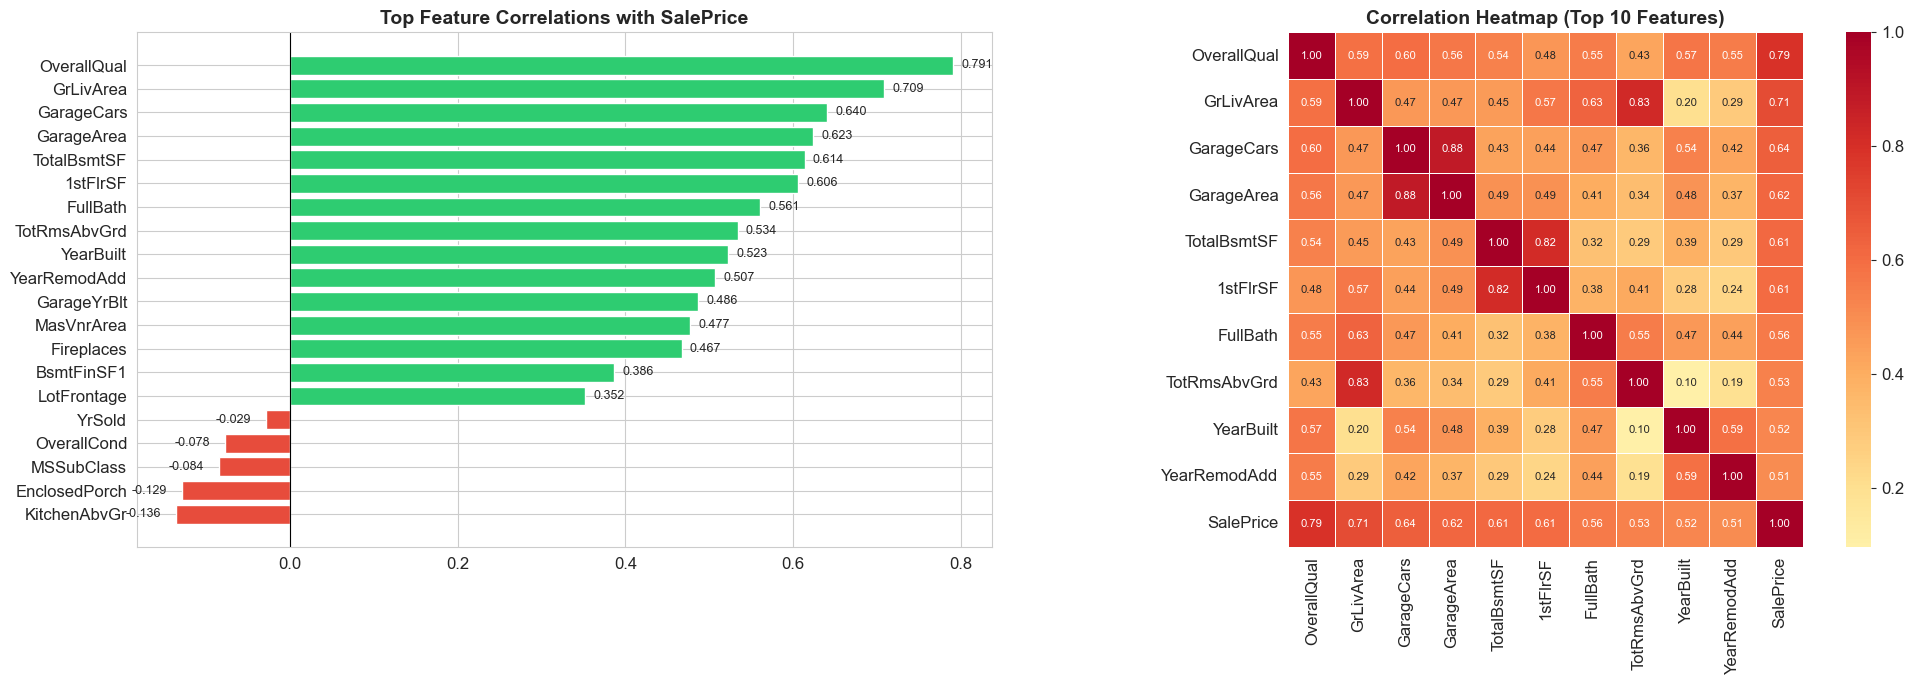

In [8]:
# 3.4 Correlation Analysis

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()
sale_corr = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Top & bottom correlations bar chart
top_n = 15
top_corr = pd.concat([sale_corr.head(top_n), sale_corr.tail(5)])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corr.values]
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_title('Top Feature Correlations with SalePrice', fontweight='bold', fontsize=14)
axes[0].axvline(x=0, color='black', linewidth=0.8)
for i, (val, name) in enumerate(zip(top_corr.values[::-1], top_corr.index[::-1])):
    axes[0].text(val + 0.01 if val > 0 else val - 0.06, i, f'{val:.3f}', va='center', fontsize=9)

# Heatmap of top correlated features
top_feats = sale_corr.head(10).index.tolist() + ['SalePrice']
sns.heatmap(train[top_feats].corr(), annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[1],
            annot_kws={'fontsize': 8})
axes[1].set_title('Correlation Heatmap (Top 10 Features)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


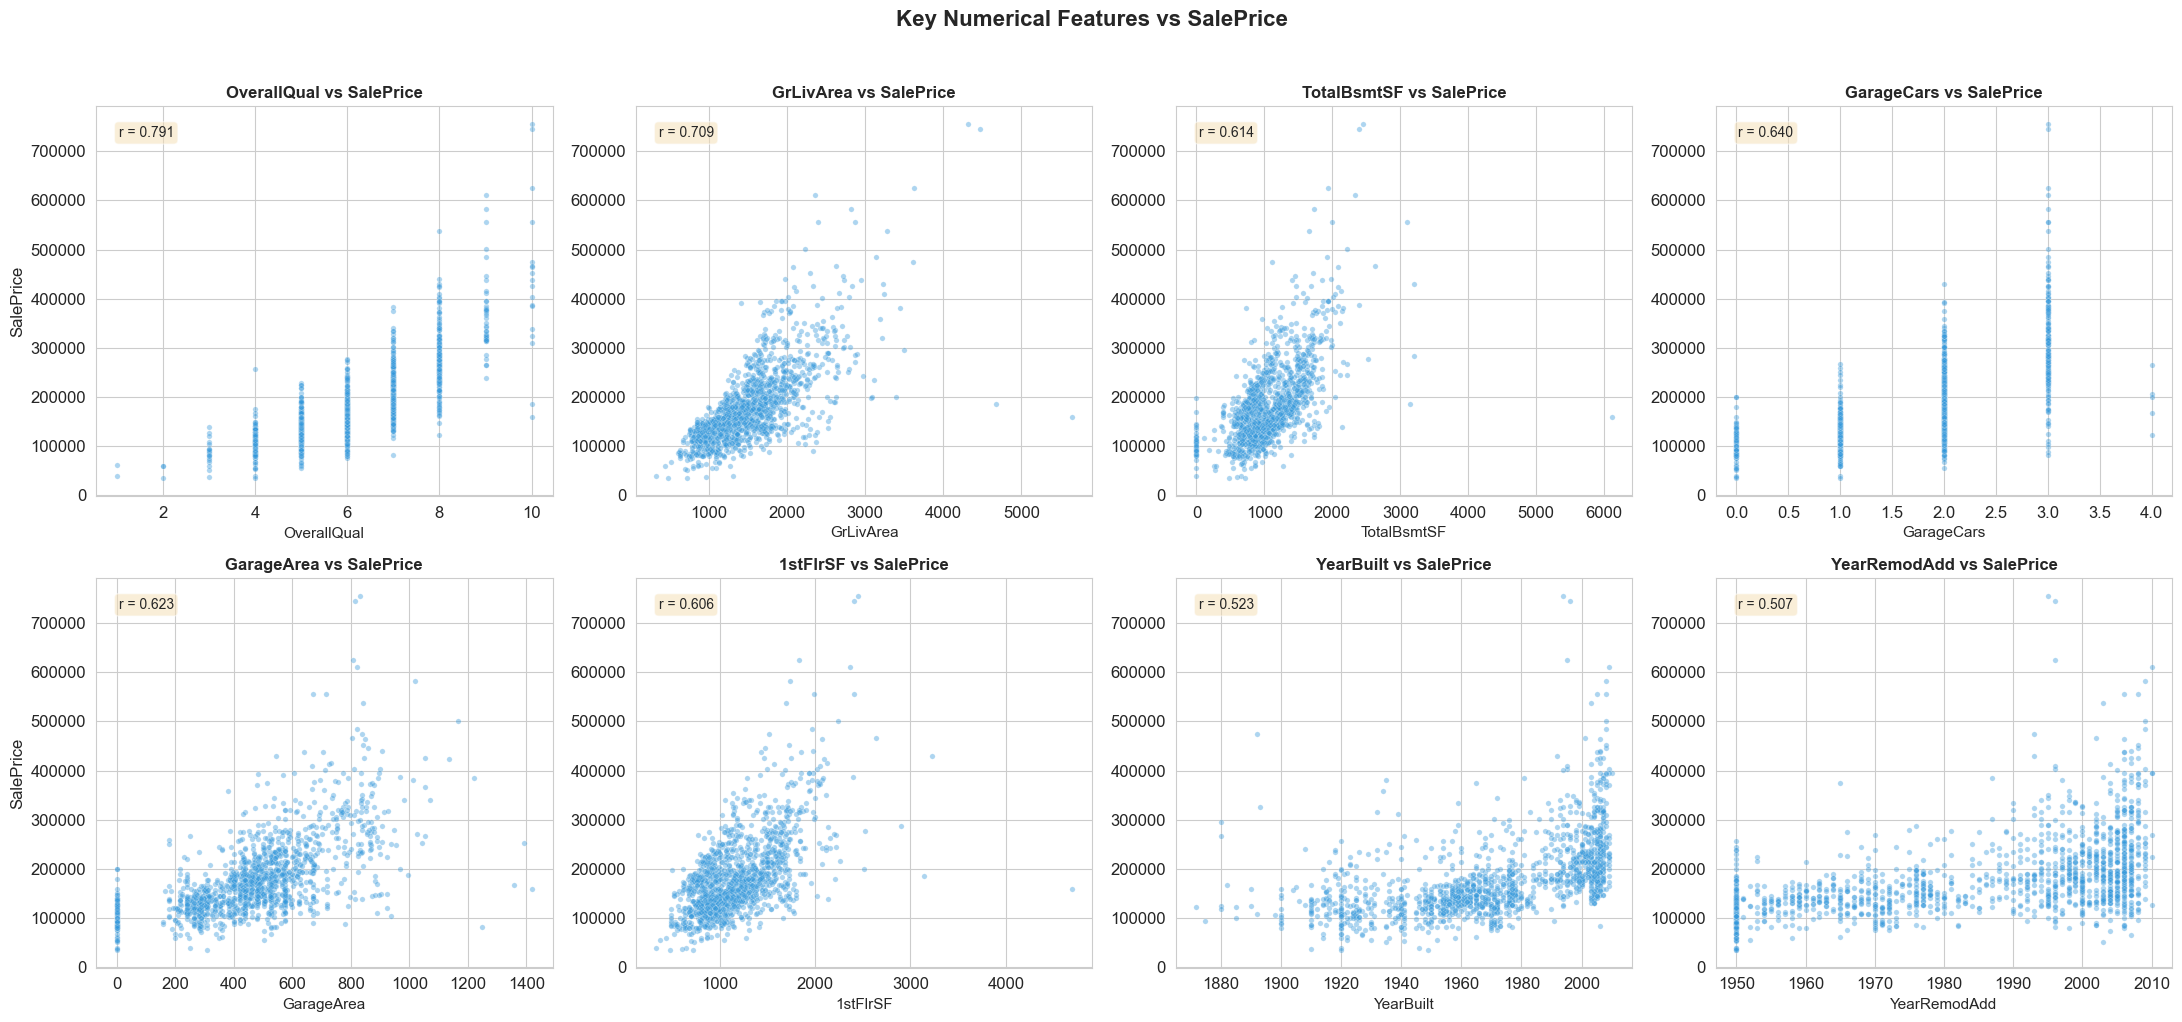

In [9]:
# 3.5 Key Numerical Features vs SalePrice

key_num_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
                    'GarageArea', '1stFlrSF', 'YearBuilt', 'YearRemodAdd']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for idx, feat in enumerate(key_num_features):
    ax = axes[idx // 4, idx % 4]
    ax.scatter(train[feat], train['SalePrice'], alpha=0.4, s=15, color='#3498db', edgecolors='white', linewidth=0.3)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SalePrice' if idx % 4 == 0 else '')
    ax.set_title(f'{feat} vs SalePrice', fontweight='bold', fontsize=12)

    r = train[[feat, 'SalePrice']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Key Numerical Features vs SalePrice', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


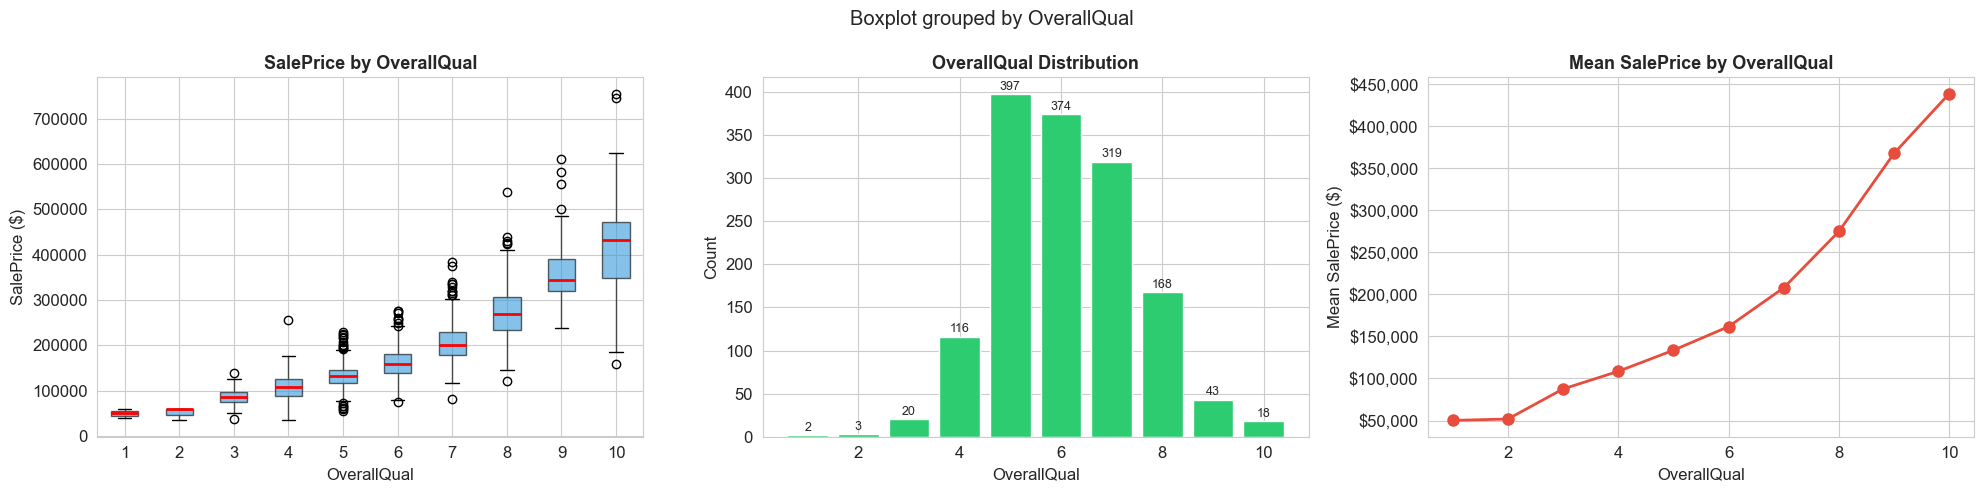

In [10]:
# 3.6 OverallQual Deep Dive


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Boxplot
train.boxplot(column='SalePrice', by='OverallQual', ax=axes[0],
              patch_artist=True,
              boxprops=dict(facecolor='#3498db', alpha=0.6),
              medianprops=dict(color='red', linewidth=2))
axes[0].set_title('SalePrice by OverallQual', fontweight='bold', fontsize=13)
axes[0].set_xlabel('OverallQual')
axes[0].set_ylabel('SalePrice ($)')
plt.sca(axes[0]); plt.title('SalePrice by OverallQual', fontweight='bold', fontsize=13)

# Count per quality level
qual_counts = train['OverallQual'].value_counts().sort_index()
axes[1].bar(qual_counts.index, qual_counts.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('OverallQual Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('OverallQual')
axes[1].set_ylabel('Count')
for i, v in enumerate(qual_counts.values):
    axes[1].text(qual_counts.index[i], v + 5, str(v), ha='center', fontsize=9)

# Mean price per quality
qual_mean = train.groupby('OverallQual')['SalePrice'].mean()
axes[2].plot(qual_mean.index, qual_mean.values, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[2].set_title('Mean SalePrice by OverallQual', fontweight='bold', fontsize=13)
axes[2].set_xlabel('OverallQual')
axes[2].set_ylabel('Mean SalePrice ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


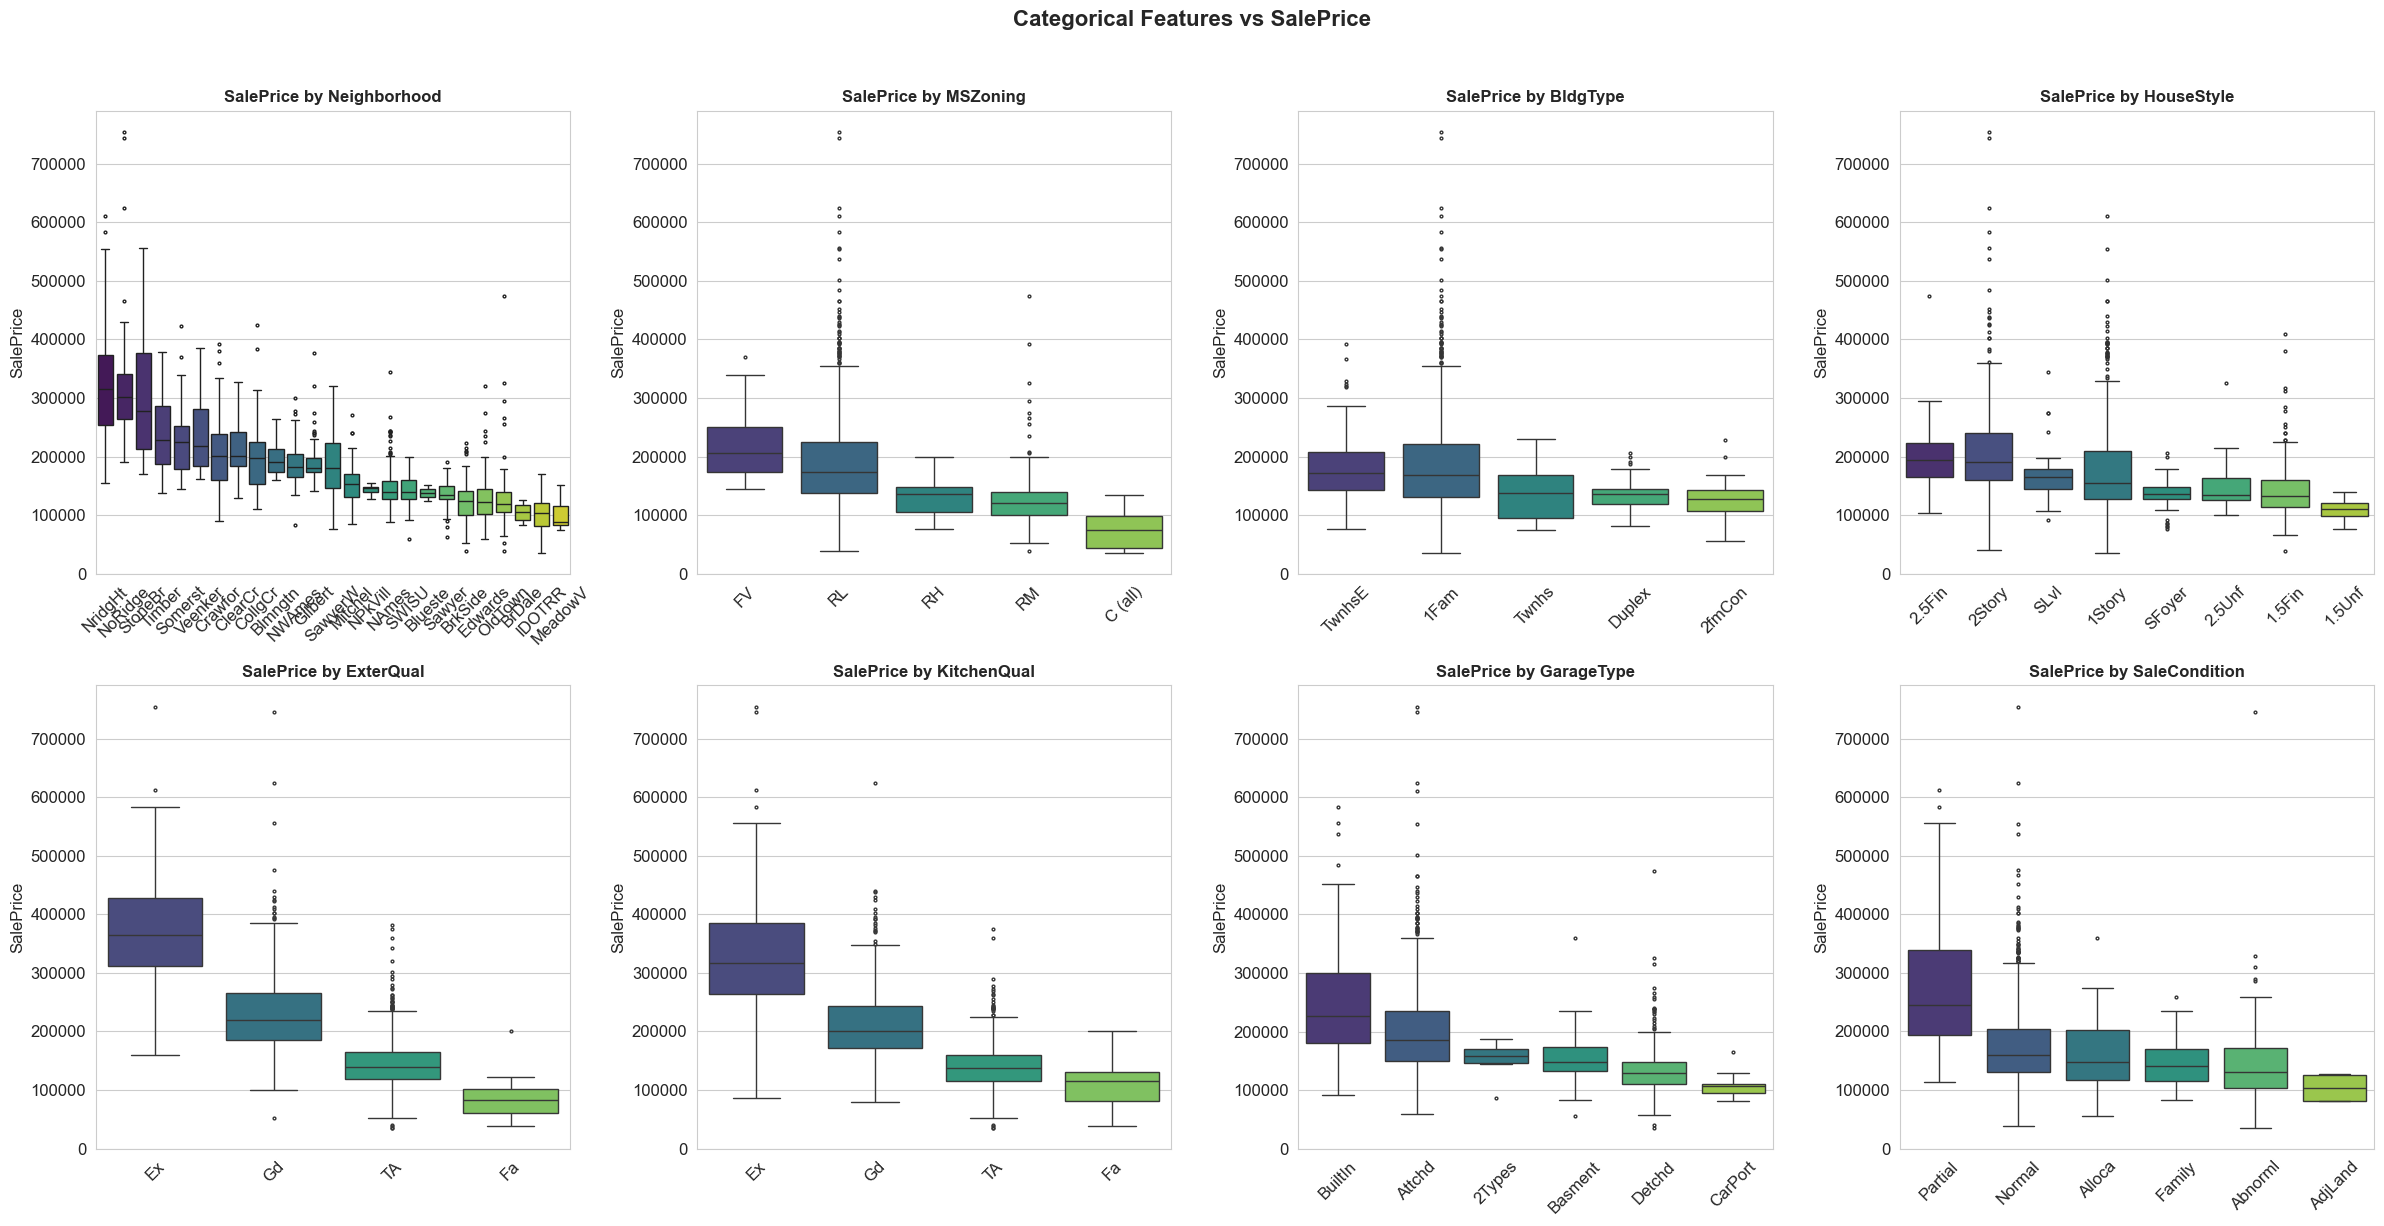

In [11]:
# 3.7 Top Categorical Features vs SalePrice

cat_features = ['Neighborhood', 'MSZoning', 'BldgType', 'HouseStyle',
                'ExterQual', 'KitchenQual', 'GarageType', 'SaleCondition']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for idx, feat in enumerate(cat_features):
    ax = axes[idx // 4, idx % 4]
    order = train.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=feat, y='SalePrice', data=train, order=order, ax=ax,
                palette='viridis', fliersize=2)
    ax.set_title(f'SalePrice by {feat}', fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.suptitle('Categorical Features vs SalePrice', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


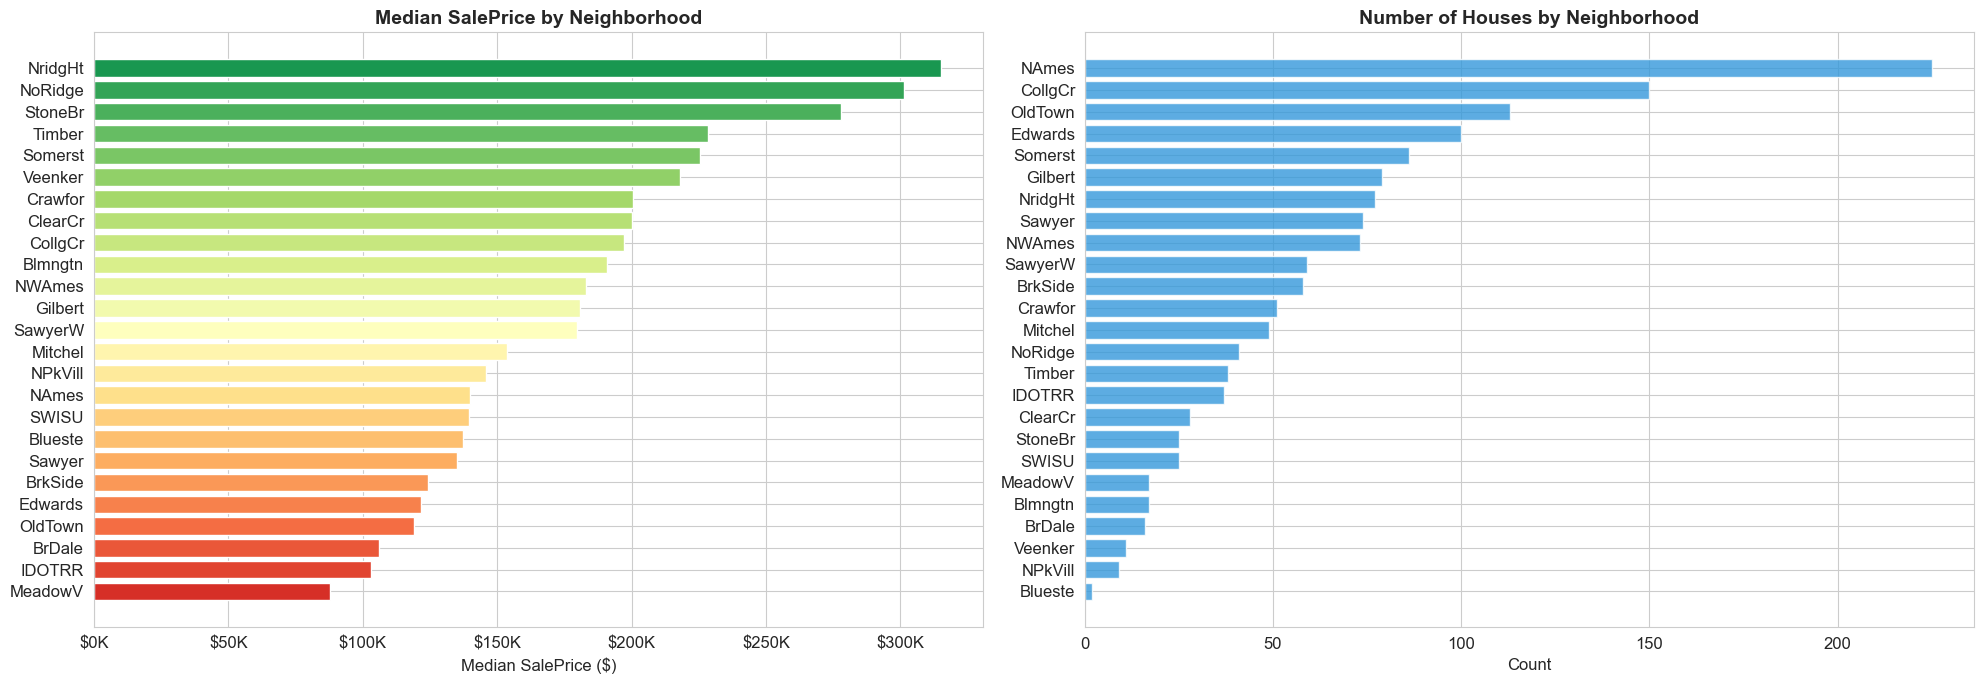

In [12]:
# 3.8 Neighborhood Analysis

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Median price by neighborhood
neigh_median = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(neigh_median)))
axes[0].barh(neigh_median.index, neigh_median.values, color=colors, edgecolor='white')
axes[0].set_title('Median SalePrice by Neighborhood', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Median SalePrice ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Count by neighborhood
neigh_count = train['Neighborhood'].value_counts().sort_values(ascending=True)
axes[1].barh(neigh_count.index, neigh_count.values, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Number of Houses by Neighborhood', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


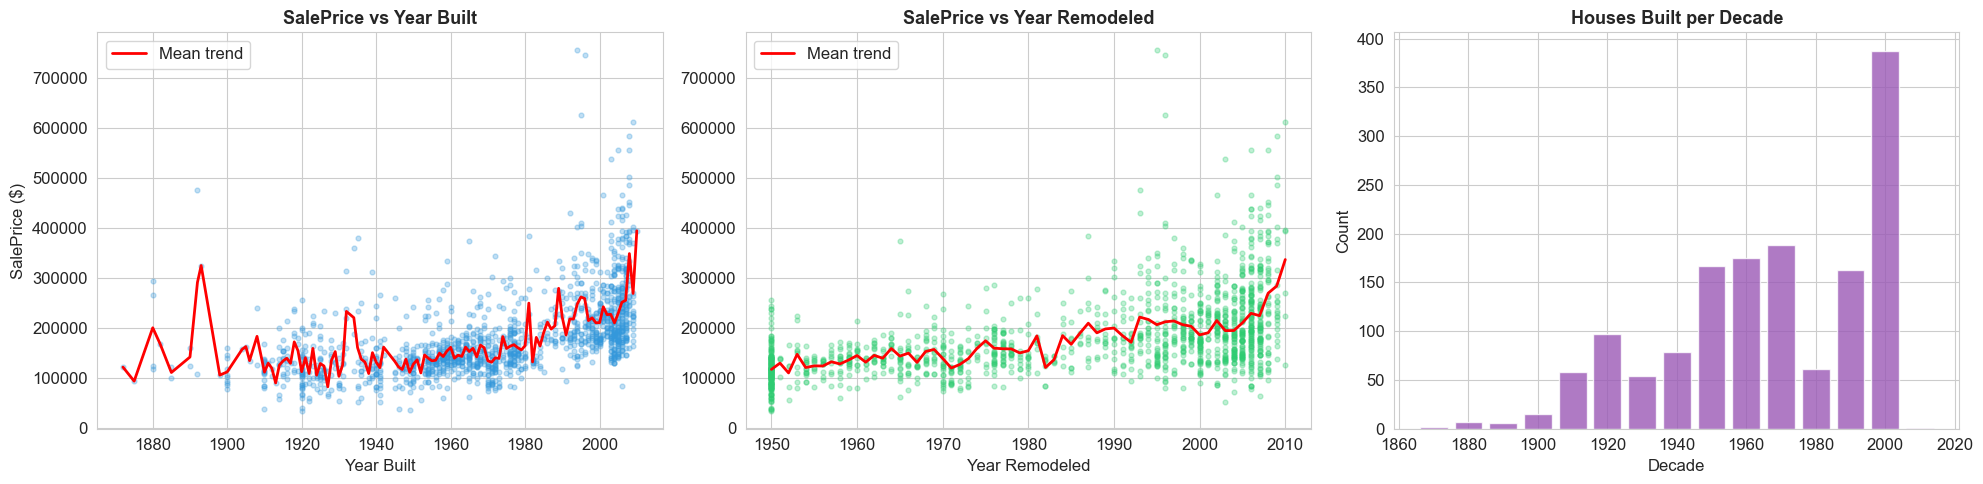

In [13]:
# 3.9 Year Built & Remodeling Trends

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Year Built vs Price
axes[0].scatter(train['YearBuilt'], train['SalePrice'], alpha=0.3, s=12, color='#3498db')
yr_mean = train.groupby('YearBuilt')['SalePrice'].mean()
axes[0].plot(yr_mean.index, yr_mean.values, color='red', linewidth=2, label='Mean trend')
axes[0].set_title('SalePrice vs Year Built', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('SalePrice ($)')
axes[0].legend()

# Year Remodeled vs Price
axes[1].scatter(train['YearRemodAdd'], train['SalePrice'], alpha=0.3, s=12, color='#2ecc71')
yr_remod_mean = train.groupby('YearRemodAdd')['SalePrice'].mean()
axes[1].plot(yr_remod_mean.index, yr_remod_mean.values, color='red', linewidth=2, label='Mean trend')
axes[1].set_title('SalePrice vs Year Remodeled', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Year Remodeled')
axes[1].legend()

# Houses built per decade
train['Decade'] = (train['YearBuilt'] // 10) * 10
decade_counts = train['Decade'].value_counts().sort_index()
axes[2].bar(decade_counts.index, decade_counts.values, width=8, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title('Houses Built per Decade', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Decade')
axes[2].set_ylabel('Count')
train.drop('Decade', axis=1, inplace=True)

plt.tight_layout()
plt.show()


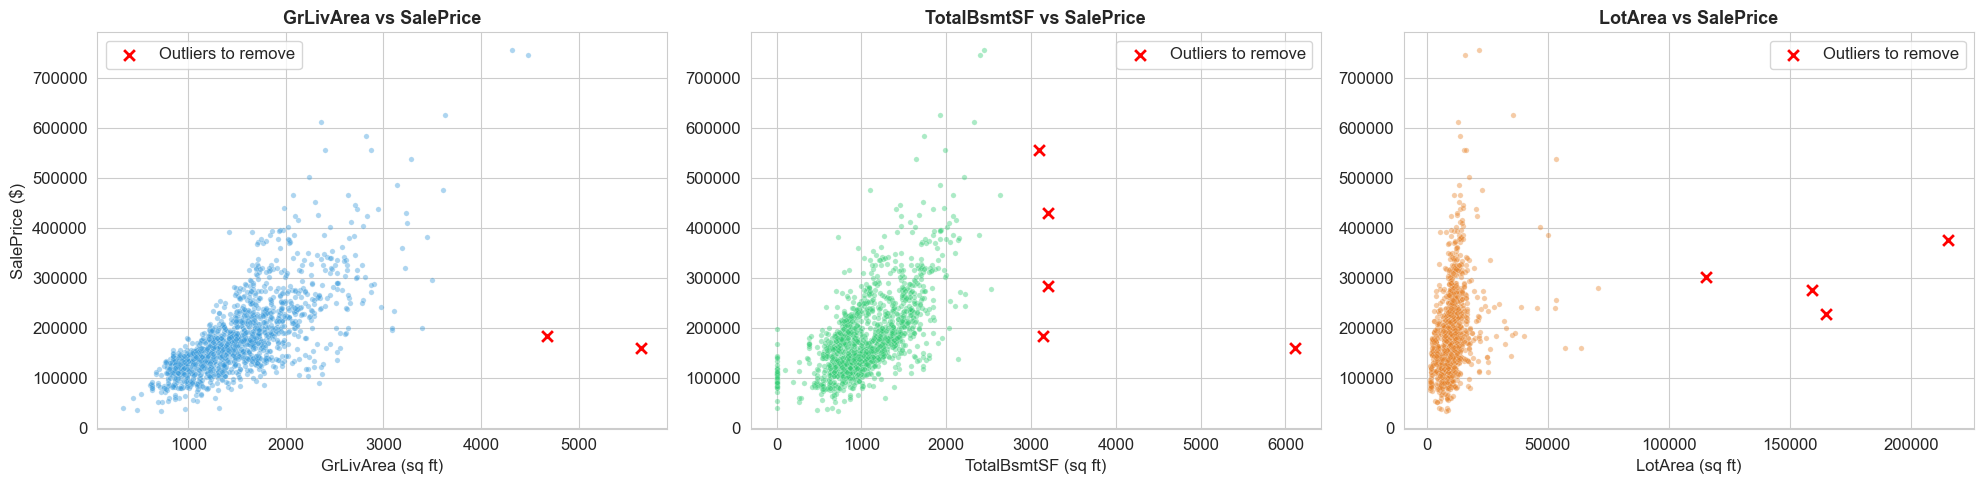

Outliers identified:
  GrLivArea > 4000 & SalePrice < $300K: 2 rows
  TotalBsmtSF > 3000:                   5 rows
  LotArea > 100000:                     4 rows


In [14]:
# 3.10 Living Area & Lot Size — Outlier Detection

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# GrLivArea
axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, s=15, color='#3498db', edgecolors='white', linewidth=0.3)
outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
axes[0].scatter(train.loc[outlier_mask, 'GrLivArea'], train.loc[outlier_mask, 'SalePrice'],
                color='red', s=60, marker='x', linewidths=2, label='Outliers to remove')
axes[0].set_title('GrLivArea vs SalePrice', fontweight='bold', fontsize=13)
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].legend()

# TotalBsmtSF
axes[1].scatter(train['TotalBsmtSF'], train['SalePrice'], alpha=0.4, s=15, color='#2ecc71', edgecolors='white', linewidth=0.3)
bsmt_outlier = train['TotalBsmtSF'] > 3000
axes[1].scatter(train.loc[bsmt_outlier, 'TotalBsmtSF'], train.loc[bsmt_outlier, 'SalePrice'],
                color='red', s=60, marker='x', linewidths=2, label='Outliers to remove')
axes[1].set_title('TotalBsmtSF vs SalePrice', fontweight='bold', fontsize=13)
axes[1].set_xlabel('TotalBsmtSF (sq ft)')
axes[1].legend()

# LotArea
axes[2].scatter(train['LotArea'], train['SalePrice'], alpha=0.4, s=15, color='#e67e22', edgecolors='white', linewidth=0.3)
lot_outlier = train['LotArea'] > 100000
axes[2].scatter(train.loc[lot_outlier, 'LotArea'], train.loc[lot_outlier, 'SalePrice'],
                color='red', s=60, marker='x', linewidths=2, label='Outliers to remove')
axes[2].set_title('LotArea vs SalePrice', fontweight='bold', fontsize=13)
axes[2].set_xlabel('LotArea (sq ft)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Outliers identified:')
print(f'  GrLivArea > 4000 & SalePrice < $300K: {outlier_mask.sum()} rows')
print(f'  TotalBsmtSF > 3000:                   {bsmt_outlier.sum()} rows')
print(f'  LotArea > 100000:                     {lot_outlier.sum()} rows')


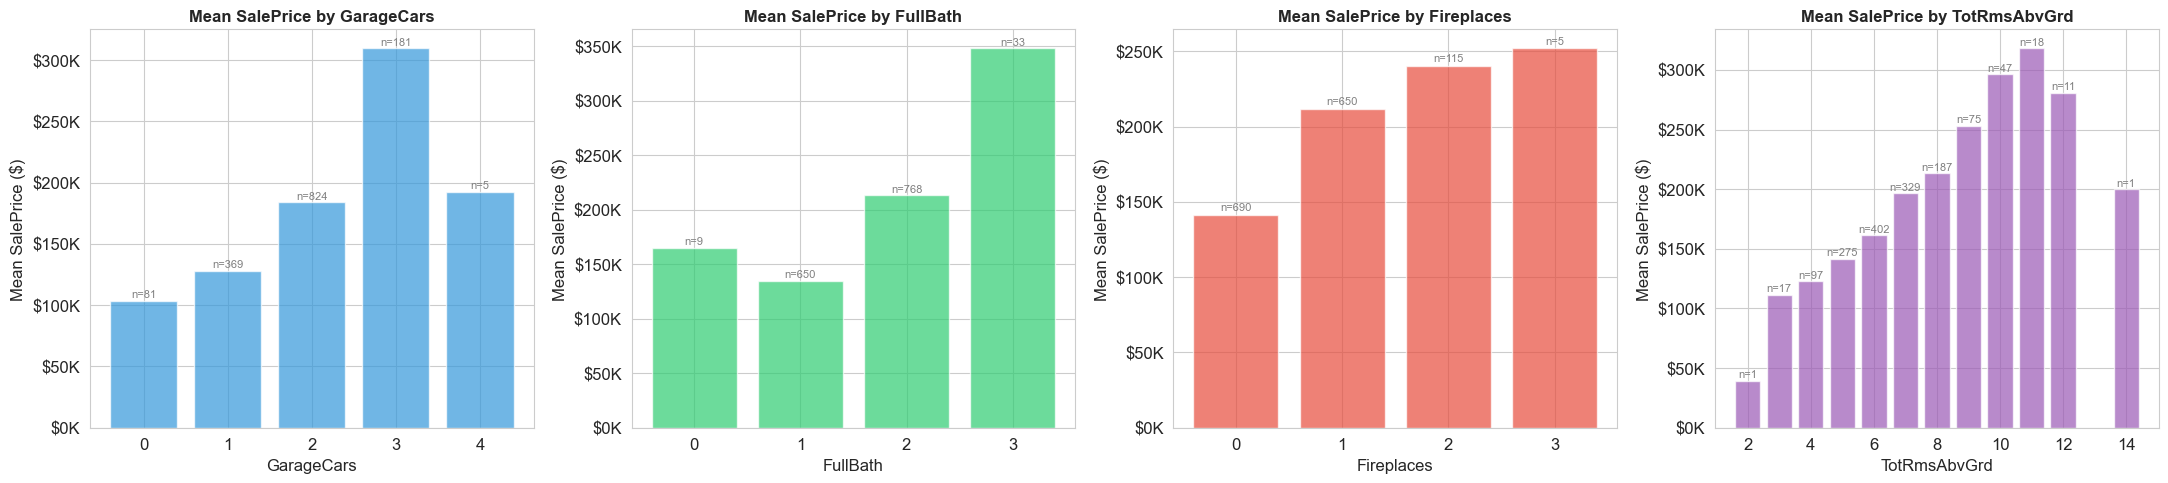

In [15]:
# 3.11 Garage, Bathroom & Fireplace Features

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, feat, color in zip(axes,
                           ['GarageCars', 'FullBath', 'Fireplaces', 'TotRmsAbvGrd'],
                           ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']):
    means = train.groupby(feat)['SalePrice'].mean()
    counts = train[feat].value_counts().sort_index()

    ax.bar(means.index, means.values, color=color, edgecolor='white', alpha=0.7)
    ax.set_title(f'Mean SalePrice by {feat}', fontweight='bold', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('Mean SalePrice ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    for i, (idx_val, mean_val) in enumerate(zip(means.index, means.values)):
        count = counts.get(idx_val, 0)
        ax.text(idx_val, mean_val + 3000, f'n={count}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()


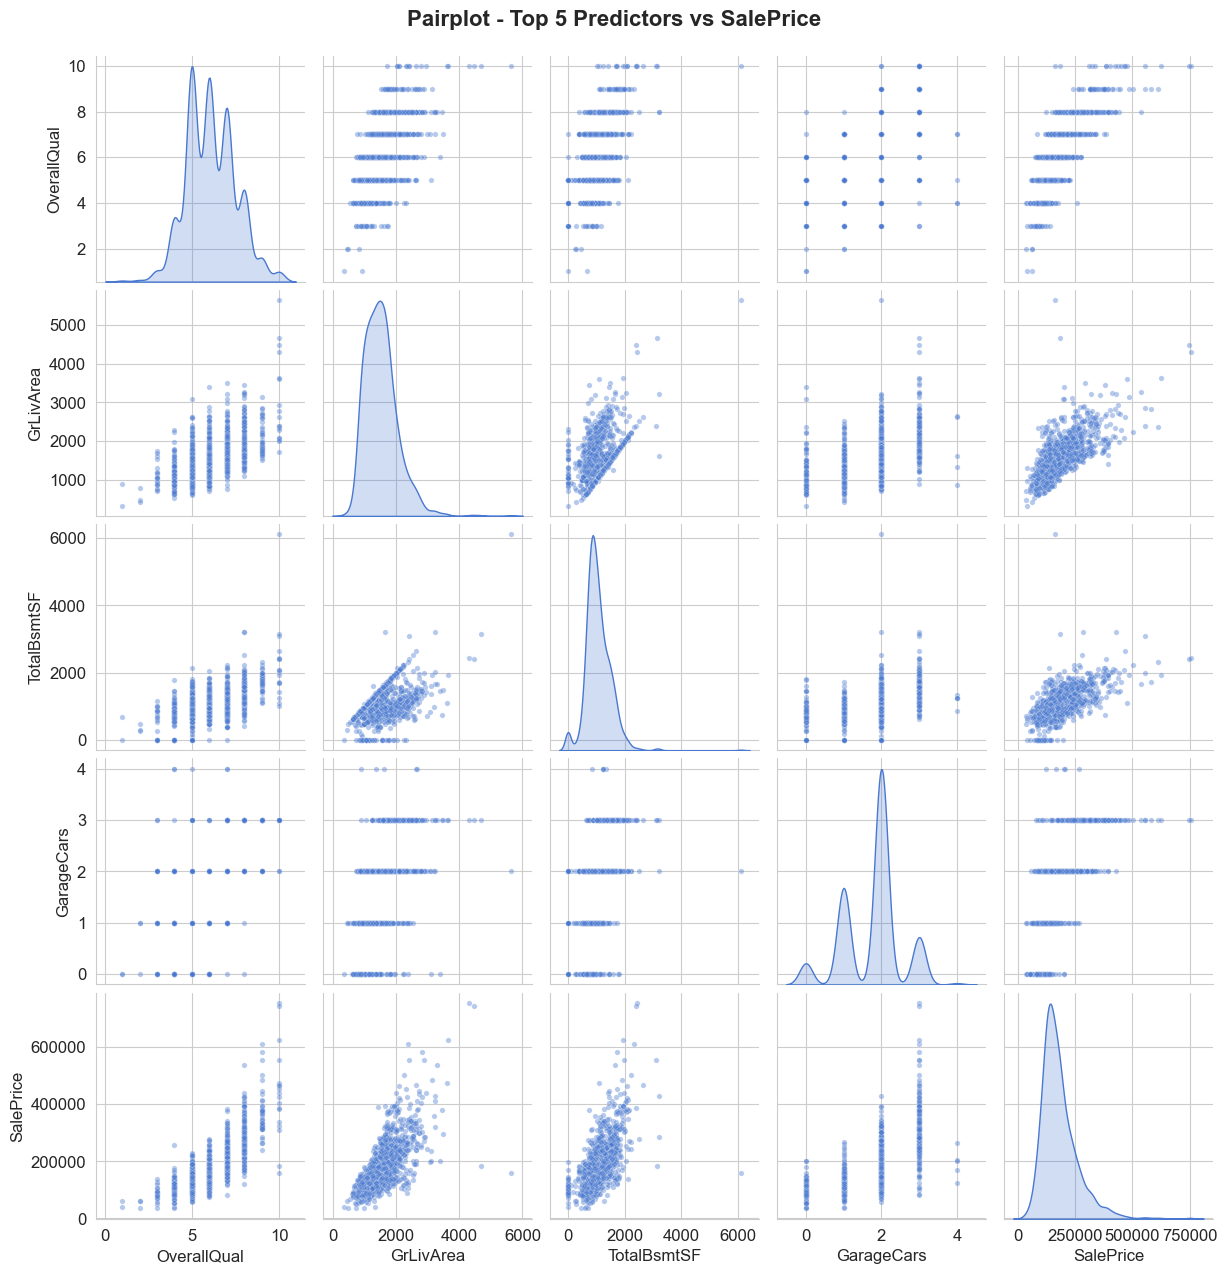

In [16]:
# 3.12 Pairplot — Top 5 Predictors

top5 = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'SalePrice']
g = sns.pairplot(train[top5], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'white'},
                 diag_kws={'fill': True})
g.figure.suptitle('Pairplot - Top 5 Predictors vs SalePrice', fontweight='bold', fontsize=16, y=1.02)
plt.show()


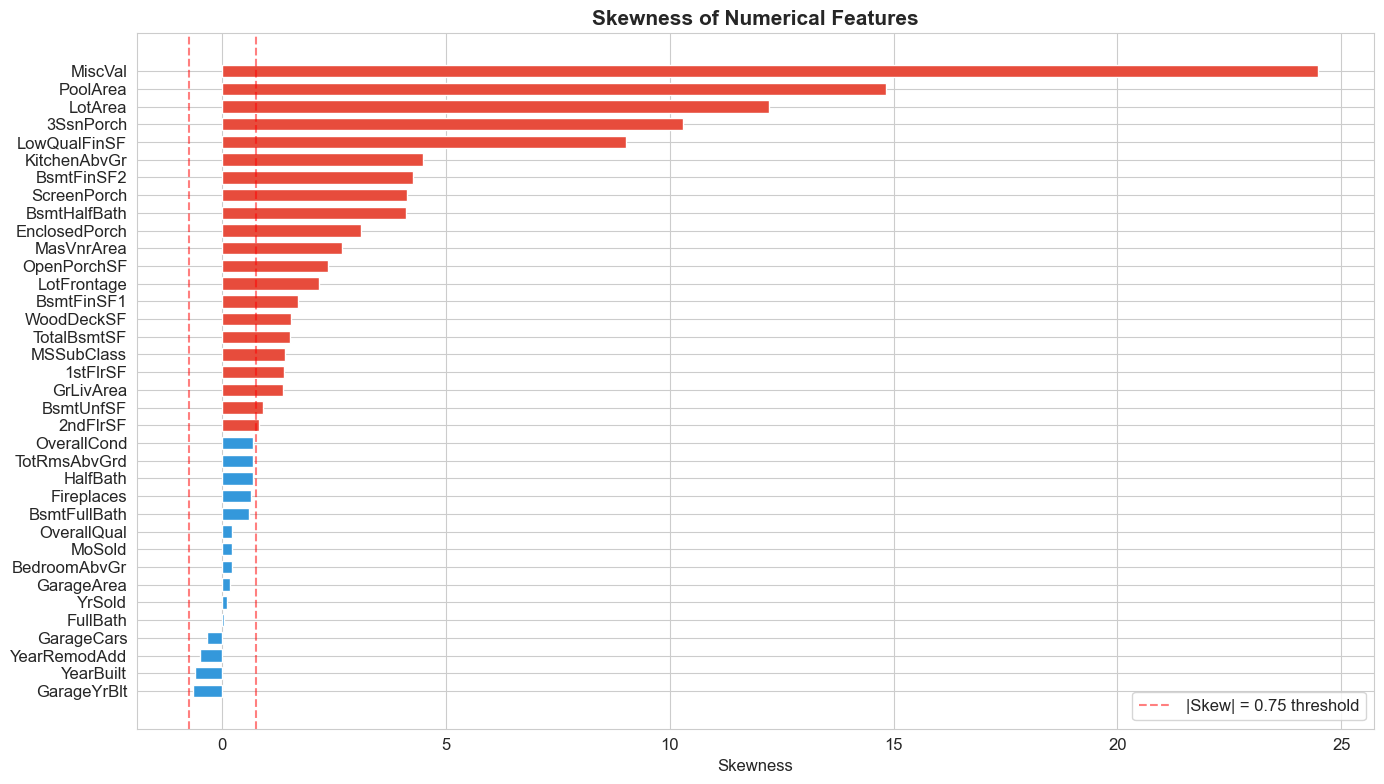

Features with |skewness| > 0.75: 21 / 36


In [17]:
# 3.13 Numerical Feature Distributions & Skewness

num_feats_list = train.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice']).tolist()
skewness = train[num_feats_list].apply(lambda x: x.skew()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if abs(s) > 0.75 else '#3498db' for s in skewness.values]
ax.barh(skewness.index[::-1], skewness.values[::-1], color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(x=0.75, color='red', linestyle='--', alpha=0.5, label='|Skew| = 0.75 threshold')
ax.axvline(x=-0.75, color='red', linestyle='--', alpha=0.5)
ax.set_title('Skewness of Numerical Features', fontweight='bold', fontsize=15)
ax.set_xlabel('Skewness')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Features with |skewness| > 0.75: {(abs(skewness) > 0.75).sum()} / {len(skewness)}')


---
# Data Preprocessing & Feature Engineering


In [18]:
# 4.1 Outlier Removal

print(f'Before: {train.shape[0]} rows')
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
train = train[train['TotalBsmtSF'] < 3000]
train = train[train['LotArea'] < 100000]
train = train.reset_index(drop=True)
print(f'After : {train.shape[0]} rows  ({1460 - train.shape[0]} outliers removed)')


Before: 1460 rows
After : 1451 rows  (9 outliers removed)


In [19]:
# 4.2 Target Transformation & Data Combination

y_train = np.log1p(train['SalePrice'])
train.drop('SalePrice', axis=1, inplace=True)
train_id = train['Id']
n_train = len(train)
combined = pd.concat([train, test], axis=0, ignore_index=True)
combined.drop('Id', axis=1, inplace=True)
print(f'Combined: {combined.shape} | Train: {n_train} | Test: {len(combined) - n_train}')


Combined: (2910, 79) | Train: 1451 | Test: 1459


In [20]:
# 4.3 Missing Value Imputation

# NaN = feature doesn't exist (no pool, no garage, etc.)
for col in ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
            'GarageType','GarageFinish','GarageQual','GarageCond',
            'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
            'BsmtFinType2','MasVnrType']:
    combined[col].fillna('None', inplace=True)

for col in ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1',
            'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
            'BsmtHalfBath','MasVnrArea']:
    combined[col].fillna(0, inplace=True)

# Genuinely missing — impute with median/mode
combined['LotFrontage'] = combined.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

for col in ['MSZoning','Functional','Electrical','KitchenQual',
            'Exterior1st','Exterior2nd','SaleType']:
    combined[col].fillna(combined[col].mode()[0], inplace=True)

combined.drop('Utilities', axis=1, inplace=True)  # no variance

remaining = combined.isnull().sum().sum()
print(f'Remaining missing values: {remaining}')


Remaining missing values: 0


In [21]:
# 4.4 Feature Engineering — Area Features

combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
combined['TotalLivArea'] = combined['GrLivArea'] + combined['BsmtFinSF1'] + combined['BsmtFinSF2']
combined['TotalPorchSF'] = (combined['OpenPorchSF'] + combined['EnclosedPorch'] +
                            combined['3SsnPorch'] + combined['ScreenPorch'] + combined['WoodDeckSF'])
combined['LotDepth'] = combined['LotArea'] / (combined['LotFrontage'] + 1)
combined['AvgRoomSize'] = combined['GrLivArea'] / (combined['TotRmsAbvGrd'] + 1)
combined['BsmtFinRatio'] = np.where(combined['TotalBsmtSF'] > 0,
    (combined['BsmtFinSF1'] + combined['BsmtFinSF2']) / combined['TotalBsmtSF'], 0)
combined['GaragePerCar'] = np.where(combined['GarageCars'] > 0,
    combined['GarageArea'] / combined['GarageCars'], 0)
combined['LivAreaToLot'] = combined['GrLivArea'] / (combined['LotArea'] + 1)
print('Area features created')


Area features created


In [22]:
# 4.5 Feature Engineering — Age & Time Features

combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']
combined['GarageAge'] = np.where(combined['GarageYrBlt'] > 0,
    combined['YrSold'] - combined['GarageYrBlt'], 0)
combined['IsRemodeled'] = (combined['YearRemodAdd'] != combined['YearBuilt']).astype(int)
combined['IsNew'] = (combined['YrSold'] == combined['YearBuilt']).astype(int)
combined['IsRecentRemod'] = (combined['RemodAge'] < 10).astype(int)
combined['SoldInPeak'] = combined['MoSold'].isin([4, 5, 6, 7]).astype(int)
print('Age & time features created')


Age & time features created


In [23]:
# 4.6 Feature Engineering — Bathroom & Room Features

combined['TotalBath'] = (combined['FullBath'] + 0.5 * combined['HalfBath'] +
                         combined['BsmtFullBath'] + 0.5 * combined['BsmtHalfBath'])
combined['TotalRooms'] = (combined['TotRmsAbvGrd'] + combined['FullBath'] +
                          combined['HalfBath'] + combined['BsmtFullBath'] + combined['BsmtHalfBath'])
print('Bathroom & room features created')


Bathroom & room features created


In [24]:
# 4.7 Feature Engineering — Quality Ordinal Encoding & Composite Scores

qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
for col in ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
            'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']:
    combined[col] = combined[col].map(qual_map).fillna(0).astype(int)

combined['BsmtExposure'] = combined['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).fillna(0).astype(int)
combined['BsmtFinType1'] = combined['BsmtFinType1'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)
combined['BsmtFinType2'] = combined['BsmtFinType2'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)
combined['GarageFinish'] = combined['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}).fillna(0).astype(int)
combined['Fence'] = combined['Fence'].map(
    {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}).fillna(0).astype(int)
combined['Functional'] = combined['Functional'].map(
    {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}).fillna(8).astype(int)
combined['LotShape'] = combined['LotShape'].map(
    {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}).fillna(0).astype(int)
combined['LandSlope'] = combined['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3}).fillna(0).astype(int)
combined['PavedDrive'] = combined['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2}).fillna(0).astype(int)
combined['Street'] = (combined['Street'] == 'Pave').astype(int)
combined['CentralAir'] = (combined['CentralAir'] == 'Y').astype(int)

# Composite quality scores
combined['OverallScore'] = combined['OverallQual'] + combined['OverallCond']
combined['ExterScore'] = combined['ExterQual'] + combined['ExterCond']
combined['BsmtScore'] = combined['BsmtQual'] + combined['BsmtCond'] + combined['BsmtExposure']
combined['GarageScore'] = combined['GarageQual'] + combined['GarageCond'] + combined['GarageFinish']
combined['TotalQualScore'] = (combined['OverallQual'] + combined['ExterQual'] + combined['BsmtQual'] +
    combined['KitchenQual'] + combined['HeatingQC'] + combined['GarageQual'] + combined['FireplaceQu'])
print('Quality features created')


Quality features created


In [25]:
# 4.8 Feature Engineering — Interaction & Polynomial Features

# Quality x Area interactions
combined['Qual_TotalSF'] = combined['OverallQual'] * combined['TotalSF']
combined['Qual_GrLivArea'] = combined['OverallQual'] * combined['GrLivArea']
combined['Qual_TotalBsmt'] = combined['OverallQual'] * combined['TotalBsmtSF']
combined['Qual_Garage'] = combined['OverallQual'] * combined['GarageArea']
combined['Qual_LotArea'] = combined['OverallQual'] * combined['LotArea']
combined['Qual_Age'] = combined['OverallQual'] * combined['HouseAge']
combined['Exter_Area'] = combined['ExterQual'] * combined['GrLivArea']
combined['Kitchen_Area'] = combined['KitchenQual'] * combined['GrLivArea']

# Polynomial features
combined['GrLivArea_sq'] = combined['GrLivArea'] ** 2
combined['TotalSF_sq'] = combined['TotalSF'] ** 2
combined['OverallQual_sq'] = combined['OverallQual'] ** 2

# Score x Area interactions
combined['GarageScore_Area'] = combined['GarageScore'] * combined['GarageArea']
combined['BsmtScore_Area'] = combined['BsmtScore'] * combined['TotalBsmtSF']

# Binary indicators
combined['HasPool'] = (combined['PoolArea'] > 0).astype(int)
combined['HasGarage'] = (combined['GarageArea'] > 0).astype(int)
combined['HasBsmt'] = (combined['TotalBsmtSF'] > 0).astype(int)
combined['HasFireplace'] = (combined['Fireplaces'] > 0).astype(int)
combined['Has2ndFloor'] = (combined['2ndFlrSF'] > 0).astype(int)
combined['HasMasVnr'] = (combined['MasVnrArea'] > 0).astype(int)
combined['HasPorch'] = (combined['TotalPorchSF'] > 0).astype(int)
print('Interaction, polynomial & binary features created')


Interaction, polynomial & binary features created


In [26]:
# 4.9 Feature Engineering — Neighborhood Target Encoding

train_temp = combined.iloc[:n_train].copy()
train_temp['target'] = y_train.values
neigh_means = train_temp.groupby('Neighborhood')['target'].mean()
combined['NeighborhoodScore'] = combined['Neighborhood'].map(neigh_means)
combined['NeighborhoodScore'].fillna(y_train.mean(), inplace=True)
combined['MSSubClass'] = combined['MSSubClass'].astype(str)

print(f'Total features: {combined.shape[1]}')


Total features: 121


In [27]:
# 4.10 Skewness Correction + One-Hot Encoding

num_feats = combined.select_dtypes(include=[np.number]).columns.tolist()
skewed = combined[num_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed[abs(skewed) > 0.75]
for col in high_skew.index:
    if (combined[col] >= 0).all():
        combined[col] = np.log1p(combined[col])
print(f'Log1p applied to {len(high_skew)} skewed features')

cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)
print(f'Final features: {combined.shape[1]}')


Log1p applied to 62 skewed features


Final features: 257


In [28]:
# 4.11 Split Back — Train / Test

X_train = combined.iloc[:n_train].copy()
X_test = combined.iloc[n_train:].copy()
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  y_train: {y_train.shape}')


X_train: (1451, 257)  |  X_test: (1459, 257)  |  y_train: (1451,)


---
# Modeling


In [29]:
# 5.1 Cross-Validation Setup (5-Fold, MAE in Dollars)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_mae(model, X=X_train, y=y_train):
    """Compute MAE in dollars via 5-fold cross-validation."""
    mae_scores = []
    for tr_idx, val_idx in kfold.split(X, y):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = np.expm1(m.predict(X.iloc[val_idx]))
        actual = np.expm1(y.iloc[val_idx])
        mae_scores.append(mean_absolute_error(actual, preds))
    return np.array(mae_scores)

def evaluate(model, name):
    mae = cv_mae(model)
    print(f'{name:<28s} | MAE($): {mae.mean():>10,.0f} +/- {mae.std():>6,.0f}')
    return mae

print('CV setup ready (5-fold)')


CV setup ready (5-fold)


In [30]:
# 5.2 Model Definitions — Tuned Hyperparameters

ridge = Ridge(alpha=12.0, random_state=42)
lasso = Lasso(alpha=0.00035, random_state=42, max_iter=50000)
enet = ElasticNet(alpha=0.00035, l1_ratio=0.9, random_state=42, max_iter=50000)

gbr = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.02, max_depth=4,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', subsample=0.75,
    loss='huber', alpha=0.9, random_state=42)

xgb = XGBRegressor(
    n_estimators=3000, learning_rate=0.02, max_depth=4,
    min_child_weight=3, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.005, reg_lambda=1.5,
    random_state=42, n_jobs=-1, verbosity=0)

lgbm = LGBMRegressor(
    n_estimators=3000, learning_rate=0.02, max_depth=4,
    num_leaves=25, min_child_samples=10,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.005, reg_lambda=1.5,
    random_state=42, n_jobs=-1, verbosity=-1)

cat = CatBoostRegressor(
    iterations=3000, learning_rate=0.02, depth=6,
    l2_leaf_reg=5, random_strength=0.5,
    bagging_temperature=0.3, border_count=128,
    random_seed=42, verbose=0)

print('Models defined')


Models defined


In [31]:
# 5.3 Individual Model Evaluation

print('=' * 60)
results = {}
for name, model in [('Ridge', ridge), ('Lasso', lasso), ('ElasticNet', enet),
                     ('GradientBoosting', gbr), ('XGBoost', xgb),
                     ('LightGBM', lgbm), ('CatBoost', cat)]:
    mae = evaluate(model, name)
    results[name] = mae
print('=' * 60)


Ridge                        | MAE($):     13,602 +/-    633


Lasso                        | MAE($):     13,559 +/-    712


ElasticNet                   | MAE($):     13,516 +/-    714


GradientBoosting             | MAE($):     13,295 +/-    634


XGBoost                      | MAE($):     13,734 +/-    864


LightGBM                     | MAE($):     14,398 +/-    756


CatBoost                     | MAE($):     13,666 +/-    648


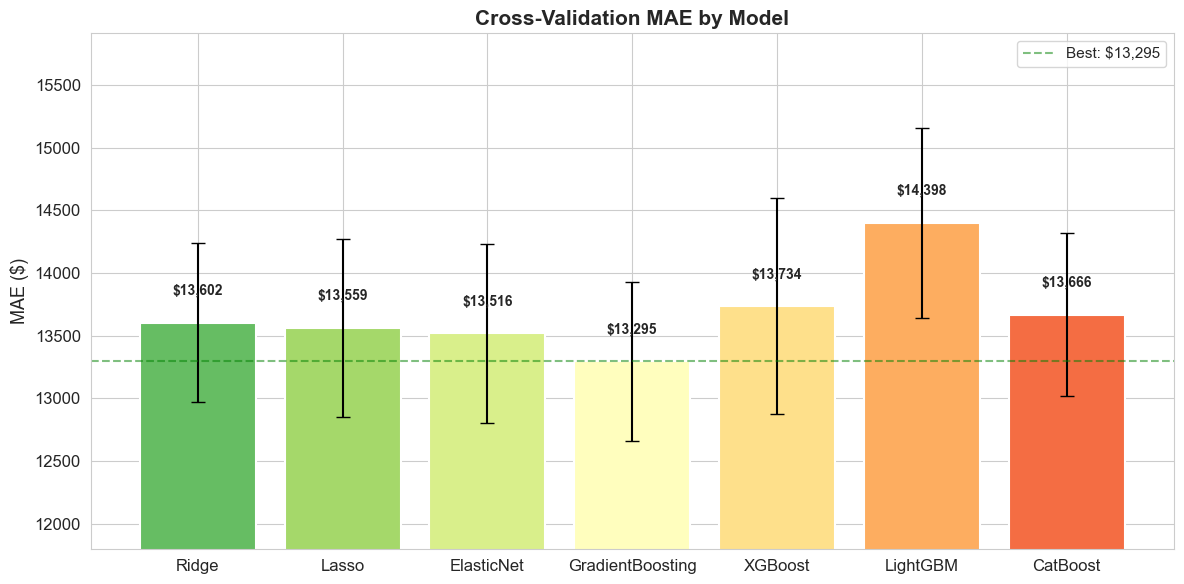

In [32]:
# 5.4 Model Comparison

model_names_list = list(results.keys())
mae_means = [results[n].mean() for n in model_names_list]
mae_stds = [results[n].std() for n in model_names_list]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(model_names_list)))
bars = ax.bar(model_names_list, mae_means, yerr=mae_stds, capsize=5,
              color=colors, edgecolor='white', linewidth=1.5)

ax.set_ylabel('MAE ($)', fontsize=13)
ax.set_title('Cross-Validation MAE by Model', fontweight='bold', fontsize=15)
ax.set_ylim(bottom=min(mae_means) - 1500)

for bar, mean_val in zip(bars, mae_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'${mean_val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=min(mae_means), color='green', linestyle='--', alpha=0.5, label=f'Best: ${min(mae_means):,.0f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [33]:
# 5.5 Train All Models on Full Data

print('Training all models...')
for name, m in [('Ridge', ridge), ('Lasso', lasso), ('ElasticNet', enet),
                ('GBR', gbr), ('XGBoost', xgb), ('LightGBM', lgbm), ('CatBoost', cat)]:
    m.fit(X_train, y_train)
    print(f'  {name} done')
print('All models trained')


Training all models...
  Ridge done


  Lasso done


  ElasticNet done


  GBR done


  XGBoost done


  LightGBM done


  CatBoost done
All models trained


---
# Optimized Ensemble Blending


In [34]:
# 6.1 OOF Predictions + scipy.optimize Weights

model_names = ['lasso', 'enet', 'ridge', 'gbr', 'xgb', 'lgbm', 'catboost']
model_templates = [
    Lasso(alpha=0.00035, random_state=42, max_iter=50000),
    ElasticNet(alpha=0.00035, l1_ratio=0.9, random_state=42, max_iter=50000),
    Ridge(alpha=12.0, random_state=42),
    GradientBoostingRegressor(n_estimators=3000, learning_rate=0.02, max_depth=4,
        min_samples_split=10, min_samples_leaf=5, max_features='sqrt',
        subsample=0.75, loss='huber', alpha=0.9, random_state=42),
    XGBRegressor(n_estimators=3000, learning_rate=0.02, max_depth=4,
        min_child_weight=3, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.005, reg_lambda=1.5, random_state=42, n_jobs=-1, verbosity=0),
    LGBMRegressor(n_estimators=3000, learning_rate=0.02, max_depth=4,
        num_leaves=25, min_child_samples=10, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.005, reg_lambda=1.5, random_state=42, n_jobs=-1, verbosity=-1),
    CatBoostRegressor(iterations=3000, learning_rate=0.02, depth=6,
        l2_leaf_reg=5, random_strength=0.5, bagging_temperature=0.3,
        border_count=128, random_seed=42, verbose=0),
]

oof_preds = np.zeros((n_train, len(model_templates)))
blend_kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('Computing OOF predictions...')
for i, (name, mt) in enumerate(zip(model_names, model_templates)):
    for tr_idx, val_idx in blend_kf.split(X_train, y_train):
        m = clone(mt)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_preds[val_idx, i] = m.predict(X_train.iloc[val_idx])
    print(f'  {name} done')

def mae_obj(w):
    w = np.abs(w); w = w / w.sum()
    return mean_absolute_error(np.expm1(y_train), np.expm1(oof_preds @ w))

res = minimize(mae_obj, np.ones(len(model_templates)) / len(model_templates),
               method='Nelder-Mead', options={'maxiter': 10000, 'xatol': 1e-8})
opt_w = np.abs(res.x); opt_w = opt_w / opt_w.sum()

print(f'\nOptimal weights:')
for name, w in zip(model_names, opt_w):
    print(f'  {name:<12s}: {w:.4f}')
print(f'\nOOF MAE: ${mae_obj(opt_w):,.0f}')


Computing OOF predictions...


  lasso done


  enet done
  ridge done


  gbr done


  xgb done


  lgbm done


  catboost done



Optimal weights:
  lasso       : 0.0403
  enet        : 0.4067
  ridge       : 0.0185
  gbr         : 0.4339
  xgb         : 0.0892
  lgbm        : 0.0060
  catboost    : 0.0053

OOF MAE: $12,700


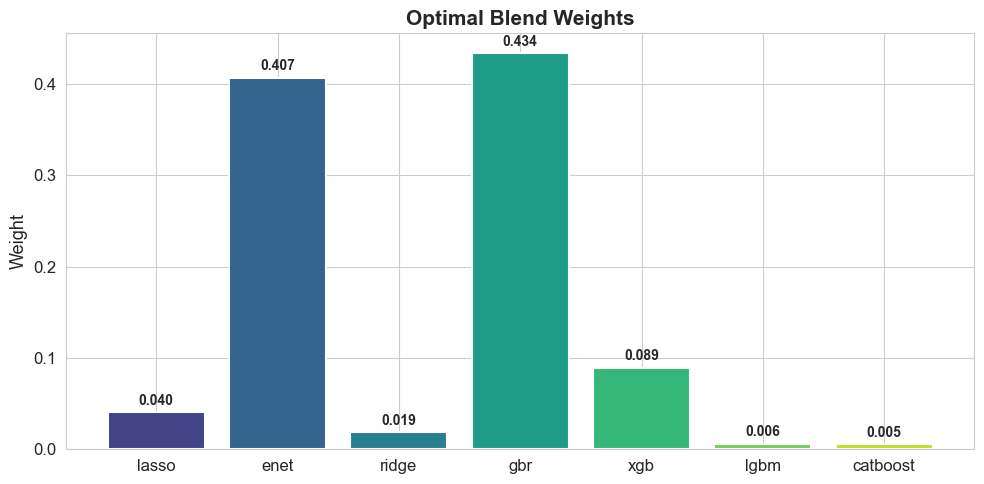

In [35]:
# 6.2 Blend Weights Visualization

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(model_names)))
bars = ax.bar(model_names, opt_w, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Weight', fontsize=13)
ax.set_title('Optimal Blend Weights', fontweight='bold', fontsize=15)
for bar, w in zip(bars, opt_w):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{w:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


---
# Final Prediction & Submission


In [36]:
# 7.1 Final Prediction — Optimally Weighted Blend

preds_dict = {
    'lasso': lasso.predict(X_test), 'enet': enet.predict(X_test),
    'ridge': ridge.predict(X_test), 'gbr': gbr.predict(X_test),
    'xgb': xgb.predict(X_test), 'lgbm': lgbm.predict(X_test),
    'catboost': cat.predict(X_test),
}
pred_matrix = np.column_stack([preds_dict[n] for n in model_names])
final_log = pred_matrix @ opt_w
final_preds = np.maximum(np.expm1(final_log), 0)

print(f'Predictions summary:')
print(f'  Min    : ${final_preds.min():>12,.0f}')
print(f'  Max    : ${final_preds.max():>12,.0f}')
print(f'  Mean   : ${final_preds.mean():>12,.0f}')
print(f'  Median : ${np.median(final_preds):>12,.0f}')


Predictions summary:
  Min    : $      48,129
  Max    : $     763,377
  Mean   : $     178,565
  Median : $     156,748


In [37]:
# 7.2 Submission

submission = pd.DataFrame({'Id': test_id, 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)
print(f'Saved: submission.csv ({len(submission)} rows)')
print()
submission.head(10)


Saved: submission.csv (1459 rows)



,Id,SalePrice
0,1461,121592.333293
1,1462,160797.867708
2,1463,185064.634338
3,1464,197917.748532
4,1465,190228.207129
5,1466,174016.746392
6,1467,179531.509913
7,1468,164913.240212
8,1469,185241.816891
9,1470,122424.589420


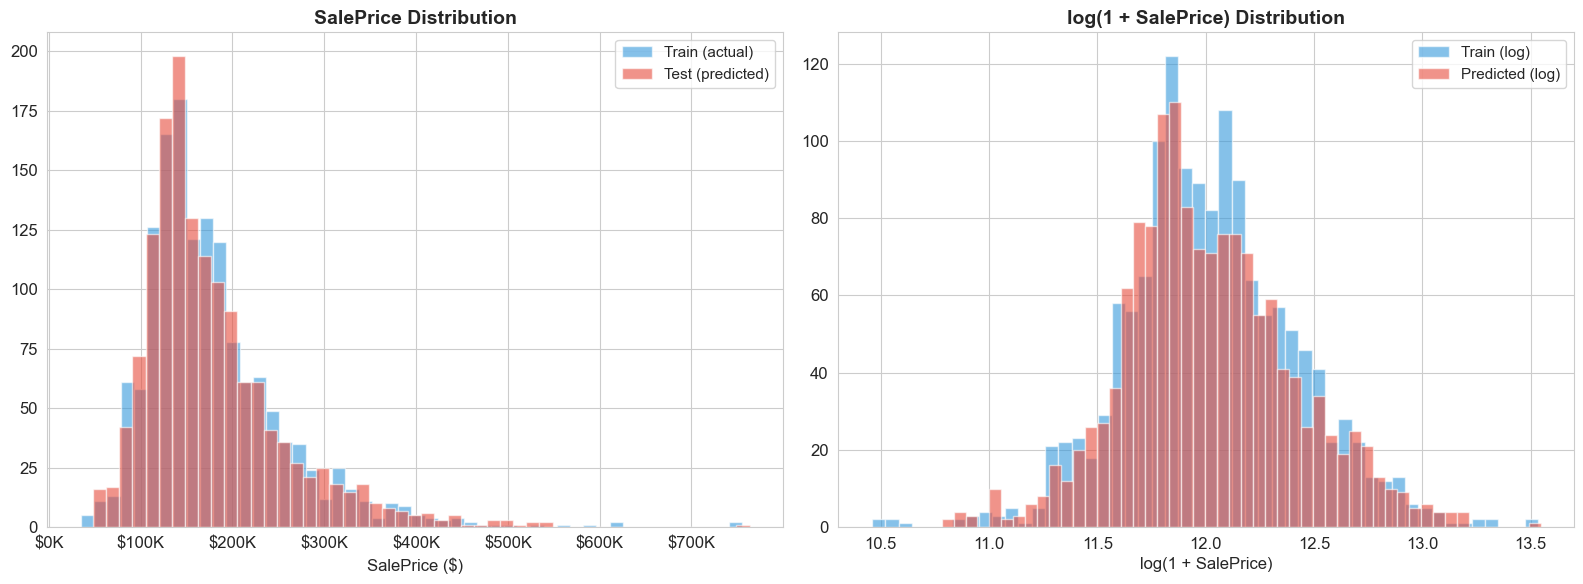

Pipeline complete!


In [38]:
# 7.3 Distribution Comparison — Train vs Predicted

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(np.expm1(y_train), bins=50, alpha=0.6, color='#3498db', label='Train (actual)', edgecolor='white')
axes[0].hist(final_preds, bins=50, alpha=0.6, color='#e74c3c', label='Test (predicted)', edgecolor='white')
axes[0].set_title('SalePrice Distribution', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].set_xlabel('SalePrice ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

axes[1].hist(y_train, bins=50, alpha=0.6, color='#3498db', label='Train (log)', edgecolor='white')
axes[1].hist(final_log, bins=50, alpha=0.6, color='#e74c3c', label='Predicted (log)', edgecolor='white')
axes[1].set_title('log(1 + SalePrice) Distribution', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].set_xlabel('log(1 + SalePrice)')

plt.tight_layout()
plt.show()
print('Pipeline complete!')


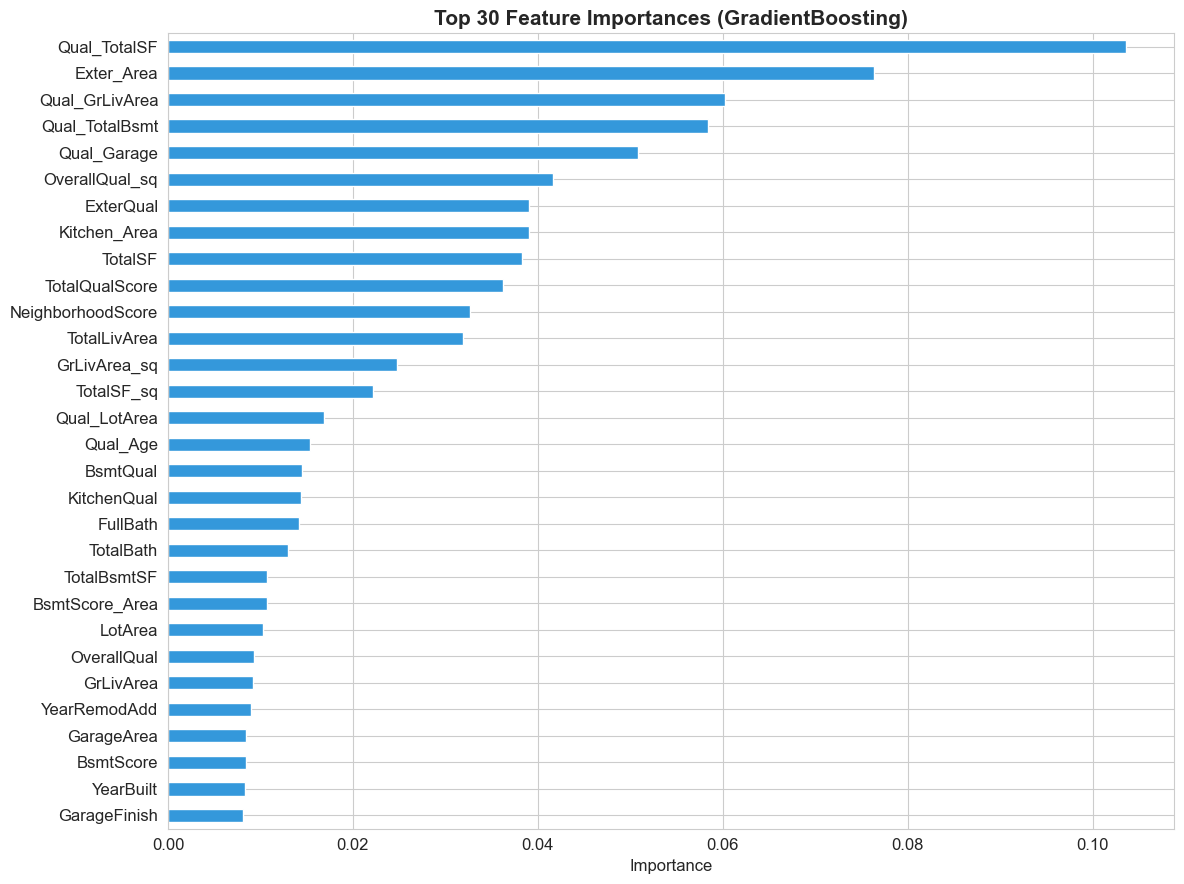

In [39]:
# 7.4 Feature Importance (GradientBoosting)

feat_imp = pd.Series(gbr.feature_importances_, index=X_train.columns)
top30 = feat_imp.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 9))
top30.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Top 30 Feature Importances (GradientBoosting)', fontweight='bold', fontsize=15)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
